k     | Raiz (xi)    | f(xi)        | Intervalo (b-a)/2
1     | 5.998398     | 6.50e+01     | 3.500000
2     | 5.198635     | 1.24e+01     | 1.499199
3     | 5.055800     | 2.19e+00     | 1.099318
4     | 5.030909     | 3.81e-01     | 1.027900
5     | 5.026591     | 6.60e-02     | 1.015454
6     | 5.025842     | 1.14e-02     | 1.013295
7     | 5.025712     | 1.98e-03     | 1.012921
O valor da raiz final é: 5.02571


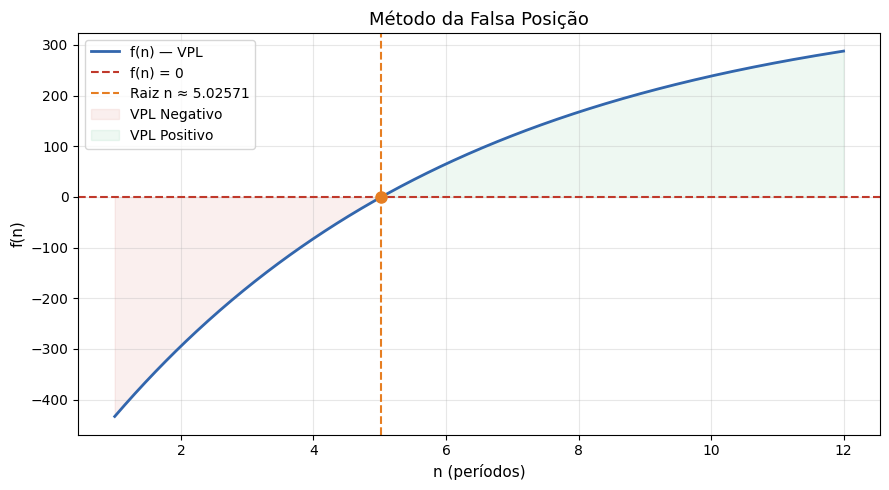

In [14]:
import math
import matplotlib.pyplot as plt
import numpy as np

f = lambda x: -600 + 200 * ((1.2**x - 1) / (0.2 * 1.2**x))

a = 3.0
b = 10.0
E = 0.01


if f(a) * f(b) < 0:
    print(f"{'k':<5} | {'Raiz (xi)':<12} | {'f(xi)':<12} | {'Intervalo (b-a)/2'}")
    cont = 0
    xi = a;
    while (math.fabs(f(xi)) > E and cont < 100):
        cont += 1
        erro_intervalo = math.fabs(b - a) / 2
        xi = (a*f(b) - b*f(a)) / (f(b) - f(a))
        print(f"{cont:<5} | {xi:<12.6f} | {f(xi):<12.2e} | {erro_intervalo:.6f}")

        if f(xi) == 0:
            break
        else:
            if f(a) * f(xi) < 0:
                b = xi
            else:
                a = xi
    if cont == 100:
        print("Número máximo de iterações atingido.")
    else:
        raiz_final = xi
        print(f"O valor da raiz final é: {raiz_final:.5f}")
else:
    print("Não há raiz neste intervalo.")
    raiz_final = None

if raiz_final is not None:
    n_vals = np.linspace(1, 12, 500)
    f_vals = [f(val) for val in n_vals]

    plt.figure(figsize=(9, 5))
    plt.plot(n_vals, f_vals, color="#3266ad", linewidth=2, label="f(n) — VPL")
    plt.axhline(0, color="#c0392b", linewidth=1.5, linestyle="--", label="f(n) = 0")
    plt.axvline(raiz_final, color="#e67e22", linewidth=1.5, linestyle="--", label=f"Raiz n ≈ {raiz_final:.5f}")
    plt.plot(raiz_final, f(raiz_final), "o", color="#e67e22", markersize=8, zorder=5)

    plt.fill_between(n_vals, f_vals, 0, where=[v < 0 for v in f_vals], alpha=0.08, color="#c0392b", label="VPL Negativo")
    plt.fill_between(n_vals, f_vals, 0, where=[v > 0 for v in f_vals], alpha=0.08, color="#27ae60", label="VPL Positivo")

    plt.xlabel("n (períodos)", fontsize=11)
    plt.ylabel("f(n)", fontsize=11)
    plt.title("Método da Falsa Posição", fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()